## Лабораторна робота 6. **Unsupervised Learning**

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

## Кластерування  

В цій лабораторній роботі Ви будете вирішувати задачу класифікації БЕЗ вчителя.

In [2]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

import os
import warnings


warnings.filterwarnings('ignore')

**Завдання 0**

Для початку необхідно завантажити вибірку `Mall_Customers` і перейменувати атрибути `Annual Income (k$)` в `Income`,`Spending Score (1-100)` в `SpendingScore`

In [3]:
def get_data(data_path: str):
  data = pd.read_csv(data_path)
  return data

customer_set = get_data("sample_data/Mall_Customers.csv")

customer_set.rename(columns={"Annual Income (k$)": "Income", "Spending Score (1-100)": "SpendingScore"}, inplace=True)

customer_set.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Завдання 1**

Підготовка даних до опрацювання

* подивитись які атрибути містить вибірка;
* вивести розмірність датасету;
* вивести основну статистичну інформацію по числовим змінним;  
* перевірити на наявність `NaN`.   

In [4]:
#yourCode
print("Info about columns: \n", customer_set.dtypes)

print("Size DSet:\n", customer_set.shape)

print("Static info: \n", customer_set.describe())

print("Sum of nulls: \n", customer_set.isnull().sum())

Info about columns: 
 CustomerID        int64
Gender           object
Age               int64
Income            int64
SpendingScore     int64
dtype: object
Size DSet:
 (200, 5)
Static info: 
        CustomerID         Age      Income  SpendingScore
count  200.000000  200.000000  200.000000     200.000000
mean   100.500000   38.850000   60.560000      50.200000
std     57.879185   13.969007   26.264721      25.823522
min      1.000000   18.000000   15.000000       1.000000
25%     50.750000   28.750000   41.500000      34.750000
50%    100.500000   36.000000   61.500000      50.000000
75%    150.250000   49.000000   78.000000      73.000000
max    200.000000   70.000000  137.000000      99.000000
Sum of nulls: 
 CustomerID       0
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64


## EDA Mall Customers

**Завдання 2**

Як Ви могли помітити по статистичній аналітиці вибірки вона містить змінну `CustomerID`. Ця змінна не впливає на аналіз даних тому її можна видалити.

In [5]:
#yourCode
customer_set.drop(columns=["CustomerID"], inplace=True)

print(customer_set.dtypes)

Gender           object
Age               int64
Income            int64
SpendingScore     int64
dtype: object


**Завдання 3**

Побудувати діаграми розподілу по змінним `Age` , `Income` та `SpendingScore`

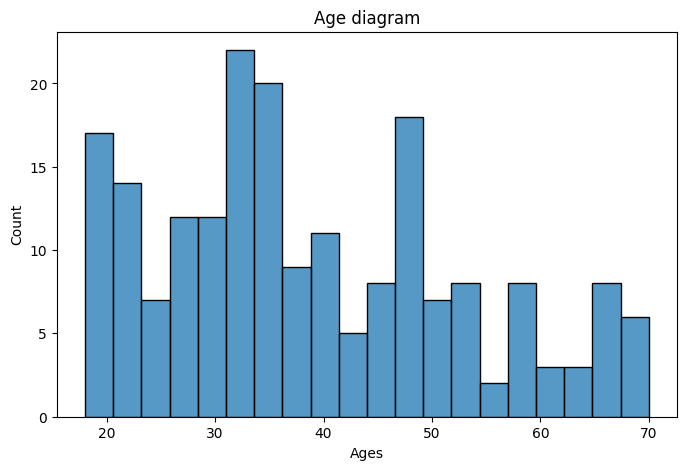

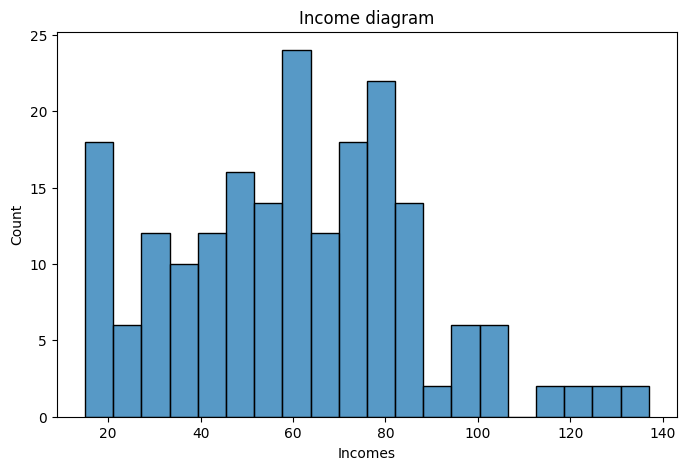

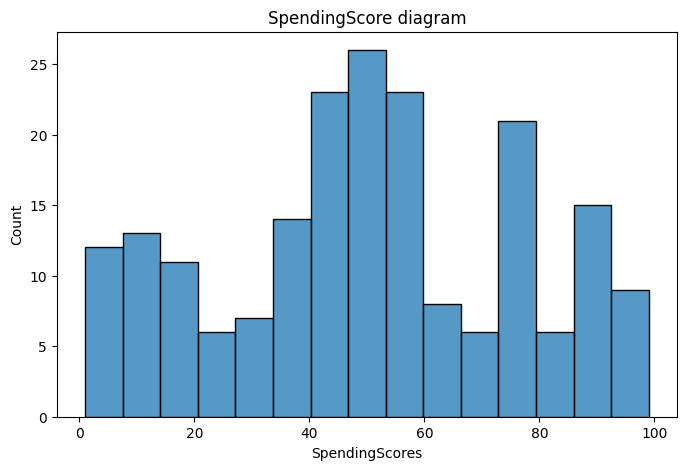

In [6]:
#yourCode
plt.figure(figsize=(8, 5))
sns.histplot(customer_set["Age"], bins = 20)
plt.title("Age diagram")
plt.xlabel("Ages")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(customer_set["Income"], bins = 20)
plt.title("Income diagram")
plt.xlabel("Incomes")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(customer_set["SpendingScore"], bins = 15)
plt.title("SpendingScore diagram")
plt.xlabel("SpendingScores")
plt.ylabel("Count")
plt.show()

**Завдання 4**

Давайте подивимось на ці змінні `Age` , `Income` та `SpendingScore` відносно змінної `Gender`.
* Побудуємо `pairplot` по всім змінним відностно змінної `Gender`:  

* Побудуємо `pairplot` використовуючи `sns.PairGrid` із заданими `(scatterplot)`, `(kdeplot)` та `(kdeplot, lw=1)` по відповідно правому верхньому куту, діагоналі і лівому нижньому кутут відносно змінної `Gender`:  


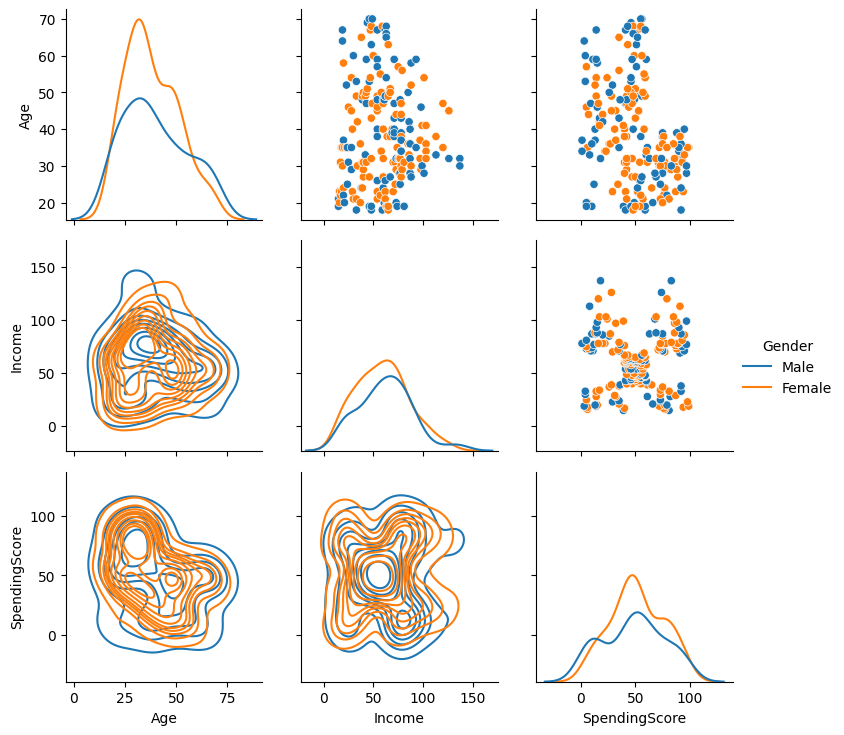

In [7]:
#yourCode

pairplotGender = sns.PairGrid(customer_set, vars=["Age", "Income", "SpendingScore"], hue="Gender")

pairplotGender.map_upper(sns.scatterplot)
pairplotGender.map_diag(sns.kdeplot)
pairplotGender.map_lower(sns.kdeplot, lw=1)

pairplotGender.add_legend()
plt.show()

**Висновки з 1-4 завдання (детальні)**

1. We see that we have the following columns CustomerID, Gender, Age, Income, SpendingScore. And the dimension of the table is 200 by 5, that is, 200 records and each of them has 5 attributes, we also see that there are no gaps in the table
2. We delete the customer IDs since it does not carry useful information and display the updated attributes
3. We display the charts for the attributes, we see that the most records are for people aged +-33 years. The most frequent income value is 60+-.

4. Women generally have a higher SpendingScore, which may indicate their greater activity in spending, while the income distribution among men is more even; The age distribution shows the largest number of clients within 30 years for both genders, and the analysis of the relationships between Age, Income, and SpendingScore does not reveal a clear linear correlation, but the graphs show clusters, which may indicate the existence of clusters among clients.

**Завдання 5**

Проаналізувати змінну `Gender`:
* вивести співвідношення по статям;
* побудувати `countplot` по `Gender`;  
* побудувати `pie`по `Gender'.  

Gender
Female    112
Male       88
Name: count, dtype: int64


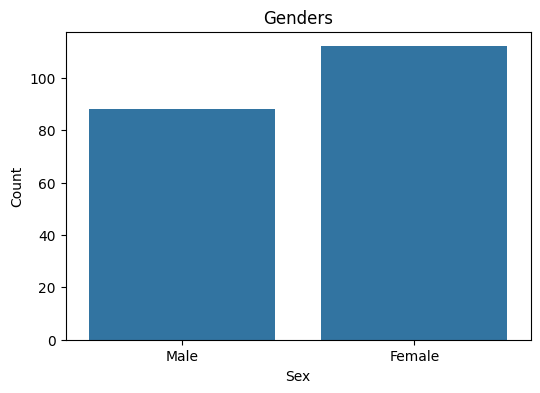

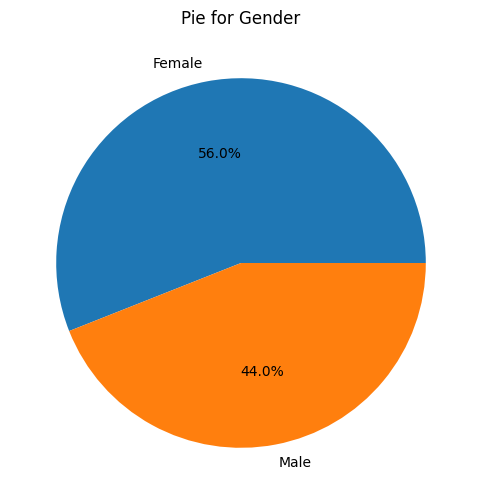

In [8]:
#yourCode
gender_counts = customer_set["Gender"].value_counts()
print(gender_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", data=customer_set)
plt.title("Genders")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Pie for Gender")
plt.show()

**Завдання 6**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінних `Age` та `Income` відносно змінної `Gender` з різними параметрами:
*  подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.

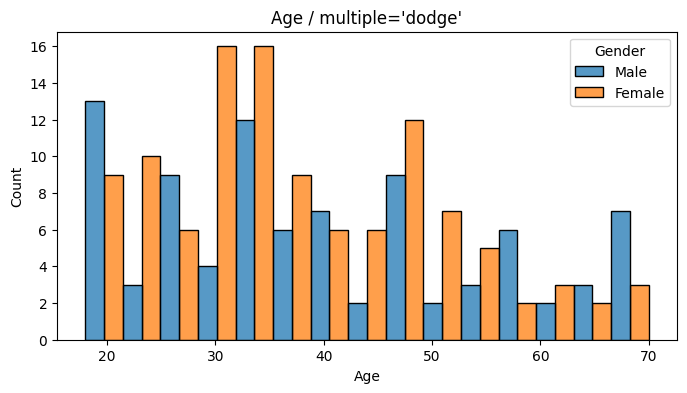

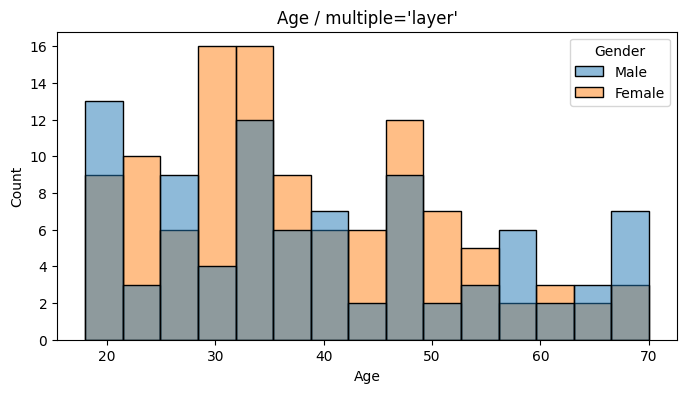

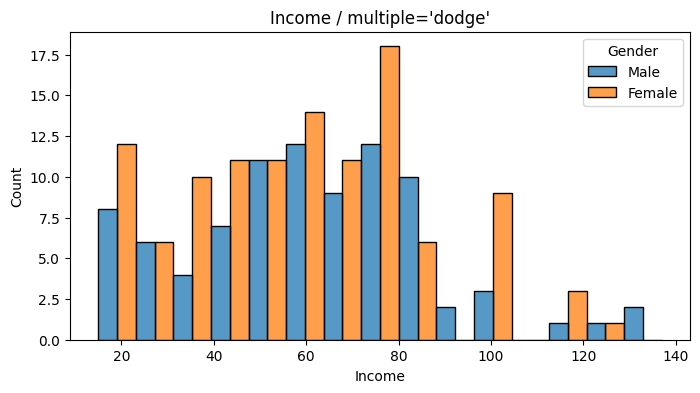

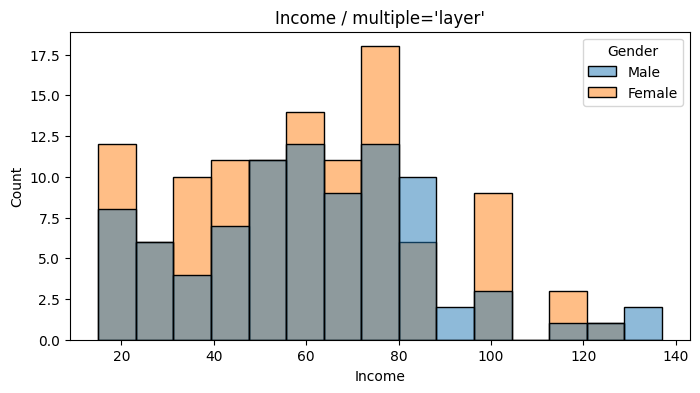

In [9]:
#yourCode

plt.figure(figsize=(8, 4))
sns.histplot(data=customer_set, x="Age", hue="Gender", multiple="dodge", bins=15)
plt.title("Age / multiple='dodge'")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=customer_set, x="Age", hue="Gender", multiple="layer", bins=15)
plt.title("Age / multiple='layer'")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=customer_set, x="Income", hue="Gender", multiple="dodge", bins=15)
plt.title("Income / multiple='dodge'")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=customer_set, x="Income", hue="Gender", multiple="layer", bins=15)
plt.title("Income / multiple='layer'")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()


**Завдання 7**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінної `SpendingScore` відносно змінної `Gender` з різними параметрами:  
* подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.



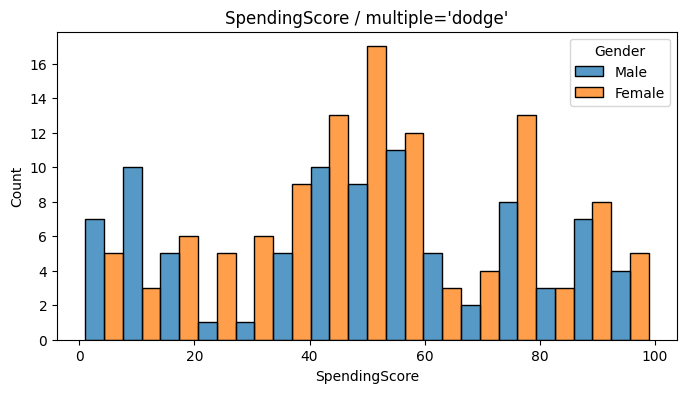

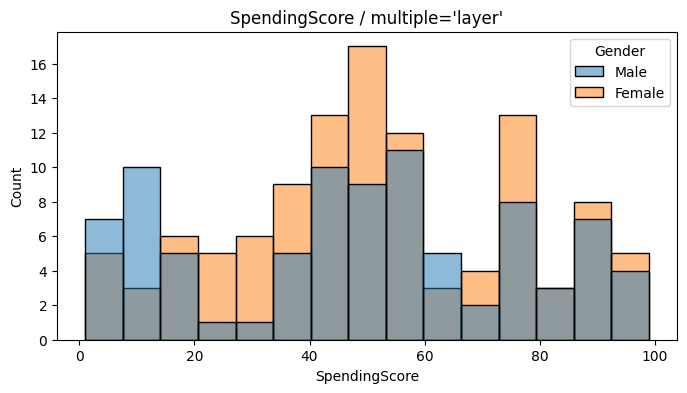

In [10]:
#yourCode


plt.figure(figsize=(8, 4))
sns.histplot(data=customer_set, x="SpendingScore", hue="Gender", multiple="dodge", bins=15)
plt.title("SpendingScore / multiple='dodge'")
plt.xlabel("SpendingScore")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=customer_set, x="SpendingScore", hue="Gender", multiple="layer", bins=15)
plt.title("SpendingScore / multiple='layer'")
plt.xlabel("SpendingScore")
plt.ylabel("Count")
plt.show()

**Завдання 8**

Побудувати `boxplot` по змінній `SpendingScore` і подивитись як відрізняються витрати відностно змінної `Gender`.

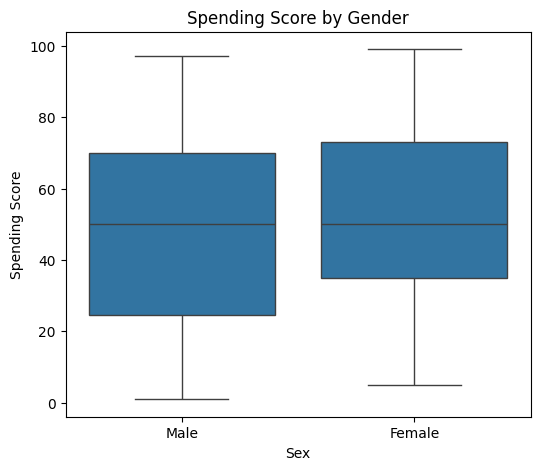

In [11]:
#yourCode

plt.figure(figsize=(6, 5))
sns.boxplot(x="Gender", y="SpendingScore", data=customer_set)
plt.title("Spending Score by Gender")
plt.xlabel("Sex")
plt.ylabel("Spending Score")
plt.show()

**Висновки з завдання 5 - 8(детальні)**

1.   Яке співвідношення груп чоловіків та жінок?
Female    112
Male       88

2.  Подивитись які можна виділити групи і як розподілені витрати відностно статі людини?
On average, men have slightly lower spending figures, but overall the statistics are +- the same. Men slightly dominate at lower costs and women dominate at higher costs
3. Чи є різниця між витратами у чоловіків та жінок?
There is no significant difference in the expenses of men and women, described in more detail in answer number 2
4. ...
4. ...

## K-means Method ##

**Завдання 9**

Як Ви могли помітити, вибірка, з якою ми працюємо, не містить ключової зміної з вірними мітками. Тому перед початком кластерування необхідно визначити (підібрати) оптимальну кількість кластерів на яке буде проведено розбиття. Для цього необхідно:
1. видалити змінну `Gender`, тому що ... **Чому?** ВІДПОВІДЬ: ЦЕ НЕ ЧИСЛОВА ЗМІННА;  
2. задати мінімальну та максимальну кількість кластерів самостійно;  
3. На прикладі алгоритму [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), для ознайомлення з тим як працювати в умовах коли кількість кластерів невідома заздалегіть і немає вірних міток з позначками до якого кластеру відноситься спостереження пропонується використати метод [Elbow](https://coderoad.ru/19197715/Scikit-Learn-K-Means-Elbow-criterion) (додаткові джерела: [article_1](https://medium.com/analytics-vidhya/elbow-method-of-k-means-clustering-algorithm-a0c916adc540#:~:text=K%2Dmeans%20clustering%20is%20an,cluster%20with%20the%20nearest%20centroid.), [article_2](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/))

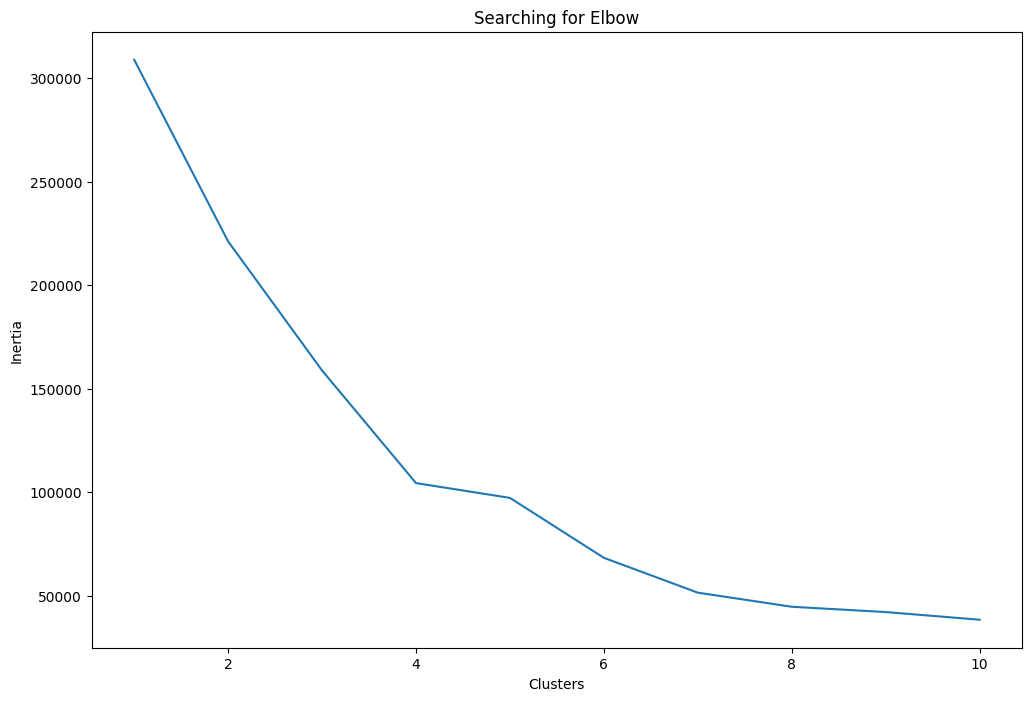

In [12]:
X = customer_set.drop(['Gender'], axis=1)
clusters = []

#yourCode
# ...
# ...
# ...
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    clusters.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(1, 11)), y=clusters, ax=ax)
ax.set_title('Searching for Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')


plt.show()

**Висновки з завдання 9 (детальні)**

1.  Необхідно навести яка кількість кластерів на Вашу думку є оптимальною (краще розглянути для порівняння делька гіпотез про кількість кластерів)
The optimal number of clusters, in my opinion, is 4, because on the graph the Elbow method clearly showed a turning point at this number - after it the decrease in inertia became insignificant, which indicates that adding another cluster does not give much improvement. For comparison, let's take 3 and 5 clusters to compare the results. For example, 3 clusters can give a more general classification, and 5 - a more detailed one, although with a large number of clusters you can risk overtraining the model.
2.   
3. ...

**Завдання 10**

Зробити двовимірну візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи змінні `Income` та `SpendingScore`.

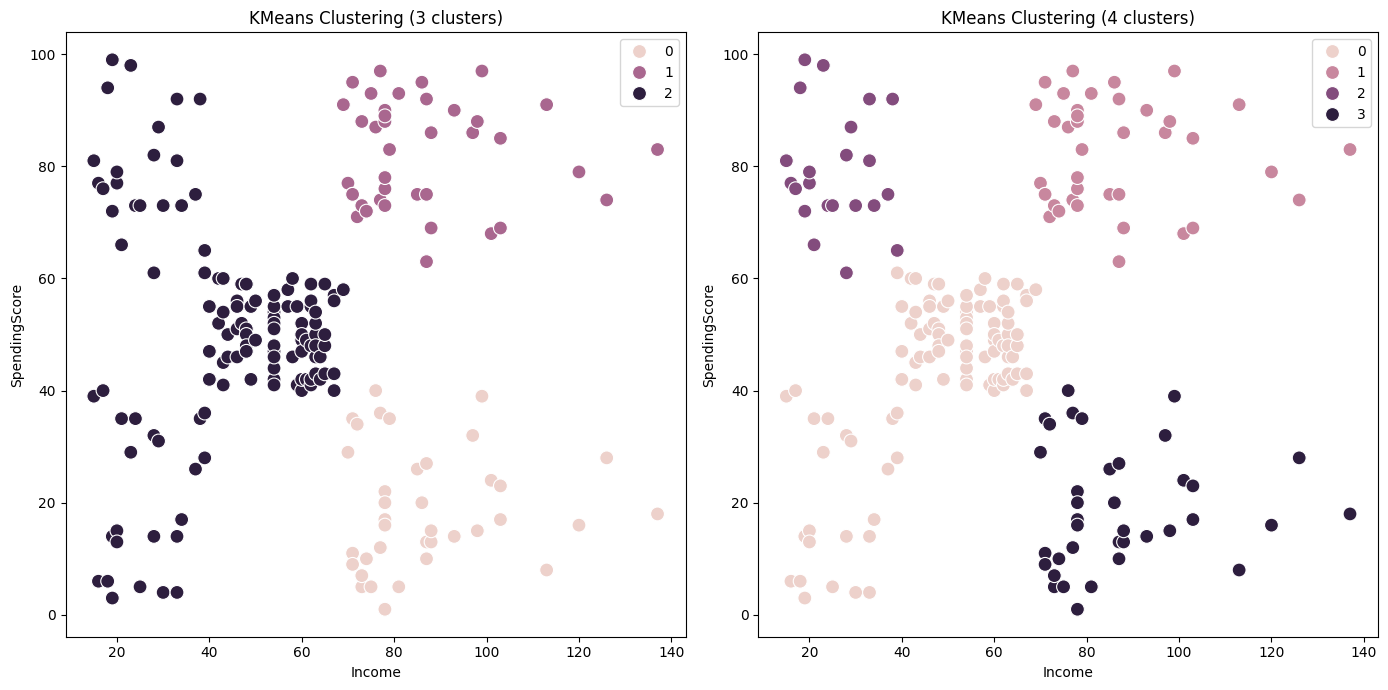

In [13]:
#yourCode
kmeans_3 = KMeans(n_clusters=3, random_state=42)
labels_3 = kmeans_3.fit_predict(customer_set[['Income', 'SpendingScore']])

kmeans_4 = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans_4.fit_predict(customer_set[['Income', 'SpendingScore']])

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(x=customer_set['Income'], y=customer_set['SpendingScore'], hue=labels_3,s=100 )
plt.title('KMeans Clustering (3 clusters)')
plt.xlabel('Income')
plt.ylabel('SpendingScore')

plt.subplot(1, 2, 2)
sns.scatterplot(x=customer_set['Income'], y=customer_set['SpendingScore'], hue=labels_4, s=100)
plt.title('KMeans Clustering (4 clusters)')
plt.xlabel('Income')
plt.ylabel('SpendingScore')

plt.tight_layout()
plt.show()

**Завдання 11**

Зробити візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи [scatter_3d](https://plotly.com/python/3d-scatter-plots/).

In [14]:
#yourCode

scatter_4 = px.scatter_3d(customer_set, x='Income', y='SpendingScore', z=labels_4,
                      color=labels_4, title='KMeans fot 4 cluster)')

kmeans_5 = KMeans(n_clusters=5, random_state=42)
labels_5 = kmeans_5.fit_predict(customer_set[['Income', 'SpendingScore']])

scatter_5 = px.scatter_3d(customer_set, x='Income', y='SpendingScore', z=labels_5,
                      color=labels_5, title='KMeans fot 5 cluster)')


scatter_4.show()
scatter_5.show()

**Висновки з завдання 10 - 11 (детальні)**

1. Визначитась з отриманих візуалізацій яка кількість кластерів є оптимальною на Вашу думку і провести аналіз кластерів, що Ви отримали.
2.   From task 10 we can conclude that, as previously analyzed, the graphs indicate that the optimal number of clusters is 4, since if we choose the number 3, then the cluster with index 2 includes costs from 0 to 100, and there are two small groups, these clusters can be increased to 4 by splitting this large 2 cluster into two different 3. In task 11 we see that 5 clusters are not bad. solution, but this increases the chances of overtraining, so I believe that the optimal solution will be 4 clusters

## Agglomerative clustering ##

Розглянемо ще один підхід до кластеризації - [агломеративну ієрархічну кластеризацію](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

**Завдання 12**

Кластеризуйте датасет за допомогою [агломеративної ієрархічнуої кластеризації](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

Мінімально необхідні параметри, що треба налаштувати:  
* `n_clusters`: параметр, який відповідає за кільксіть кластерів на яку буде проведено розбиття вибірки;  
* `linkage`: параметр зв’язку. Цей параметр визначає, яку відстань використовувати між наборами спостережень.
* перевірте як працює цей метод з різними параметрами `linkage`  
* після кожної зміни параметрів - візуалізувати розбиття на кластери

Розрахувати матрицю відстаней для нашого набору даних:
* за допомогою методу [hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) і матриці відстаней кластеризувати дані з різними значеннями параметра `method`
* за допомогою методу [hierarchy.dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html) візуалізувати отримані результати кластеризації у вигляді дендрограм


ValueError: The condensed distance matrix must contain only finite values.

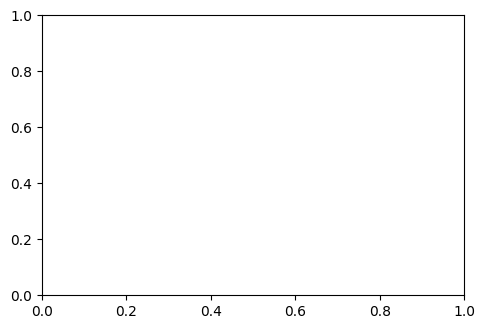

In [20]:
import scipy.cluster.hierarchy as sch

customer_set['Gender'] = customer_set['Gender'].map({'Male': 1, 'Female': 0})

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
Z_single = sch.linkage(customer_set, method='single')
sch.dendrogram(Z_single)
plt.title('Dendrogram (single)')

plt.subplot(2, 2, 2)
Z_complete = sch.linkage(customer_set, method='complete')
sch.dendrogram(Z_complete)
plt.title('Dendrogram (complete)')

plt.subplot(2, 2, 3)
Z_average = sch.linkage(customer_set, method='average')
sch.dendrogram(Z_average)
plt.title('Dendrogram (average)')

plt.subplot(2, 2, 4)
Z_ward = sch.linkage(customer_set, method='ward')
sch.dendrogram(Z_ward)
plt.title('Dendrogram (ward)')

plt.tight_layout()
plt.show()






plt.figure(figsize=(14, 7))

clustering_single = AgglomerativeClustering(n_clusters=2, linkage='single', metric='euclidean')
labels_single = clustering_single.fit_predict(customer_set)

plt.subplot(2, 2, 1)
sns.scatterplot(x=customer_set.iloc[:, 0], y=customer_set.iloc[:, 1], hue=labels_single, palette='Set1', s=100, edgecolor='black')
plt.title('Agglomerative Clustering (single)')


clustering_complete = AgglomerativeClustering(n_clusters=2, linkage='complete', metric='euclidean')
labels_complete = clustering_complete.fit_predict(customer_set)

plt.subplot(2, 2, 2)
sns.scatterplot(x=customer_set.iloc[:, 0], y=customer_set.iloc[:, 1], hue=labels_complete, palette='Set1', s=100, edgecolor='black')
plt.title('Agglomerative Clustering (complete)')


clustering_average = AgglomerativeClustering(n_clusters=2, linkage='average', metric='euclidean')
labels_average = clustering_average.fit_predict(customer_set)

plt.subplot(2, 2, 3)
sns.scatterplot(x=customer_set.iloc[:, 0], y=customer_set.iloc[:, 1], hue=labels_average, palette='Set1', s=100, edgecolor='black')
plt.title('Agglomerative Clustering (average)')


clustering_ward = AgglomerativeClustering(n_clusters=2, linkage='ward', metric='euclidean')
labels_ward = clustering_ward.fit_predict(customer_set)

plt.subplot(2, 2, 4)
sns.scatterplot(x=customer_set.iloc[:, 0], y=customer_set.iloc[:, 1], hue=labels_ward, palette='Set1', s=100, edgecolor='black')
plt.title('Agglomerative Clustering (ward)')

plt.tight_layout()
plt.show()


**Висновки з завдання 12 (детальні)**

1.Single gives long elongated clusters, which means that this method is sensitive to noise and can create chain-like associations, complete forms more clearly separated groups, which shows its ability to create compact clusters, average is a compromise between single and complete, forming moderately separated clusters, ward is the most balanced method, which creates compact and well-separated clusters. The agglomerative clustering plots of single complete average ward show clustering based on age and gender, but the variable Gender has only two values ​​0 and 1, which makes the graphical representation less informative. Single shows less clear clusters with many cases of mixed points, complete gives a clearer separation with fewer crossing points, average has a balanced but slightly mixed partition, ward provides the best distribution with minimal intersections between clusters. The general conclusion is that the Ward method is best suited for clustering because it creates compact and well-separated groups, the Single method is less effective because it forms elongated clusters that are sensitive to noise.
2.   
3. ...

**Завдання 13**

А тепер зробимо порівняльний аналіз отриманих результатів кластеризації розглянутими методами:  
* В фінальних візуалізаціях треба використовувати **однакову** (на вашу думку оптимальну) кількість кластерів!!!  

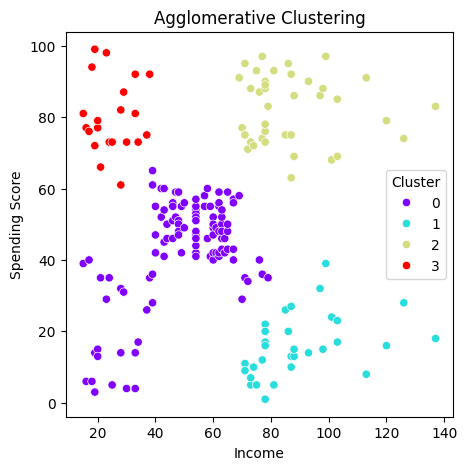

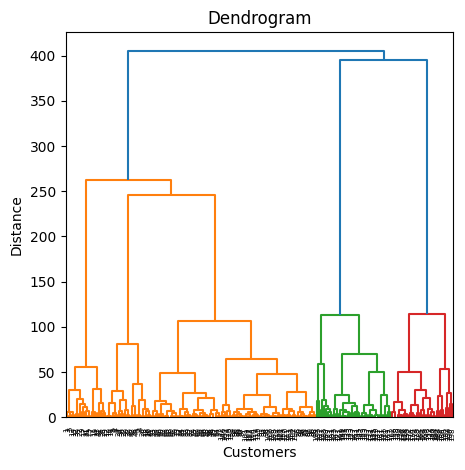

In [26]:
#yourCode

agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
customer_set['Cluster'] = agg_clustering.fit_predict(customer_set[['Income', 'SpendingScore']])

plt.figure(figsize=(5, 5))
sns.scatterplot(x=customer_set['Income'], y=customer_set['SpendingScore'], hue=customer_set['Cluster'], palette='rainbow')
plt.title('Agglomerative Clustering')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()

plt.figure(figsize=(5, 5))
linkage_matrix = hierarchy.linkage(customer_set[['Income', 'SpendingScore']], method='ward')
hierarchy.dendrogram(linkage_matrix)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()


**Висновки з завдання 13 (детальні)**

1.It is clearly visible that one group of customers has a high income but different levels of expenses, another consists of people with an average income and low expenses, there is also a group of customers with a low income but high expenses. This allows us to see certain patterns in consumer behavior.

2.   The second graph – a dendrogram – demonstrates the process of hierarchical cluster merging. It shows how objects are gradually combined into large groups depending on their similarity. Large distances between the merging levels indicate well-separated clusters, which helps to determine their optimal number.
3. ...